In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img

In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "Dataset" / "rockpaperscissors" / "train"
CLASSES = ["paper", "rock", "scissors"]  # alphabetical, matches class indices below

for cls in CLASSES:
    print(f"{cls:>8}: {len(list((DATA_DIR / cls).glob('*.png')))} images")

   paper: 712 images
    rock: 726 images
scissors: 750 images


In [3]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42
SPLIT = 0.4

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=SPLIT,
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=SPLIT)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False,
)

print("\nclass indices:", train_generator.class_indices)

Found 1314 images belonging to 3 classes.


Found 874 images belonging to 3 classes.



class indices: {'paper': 0, 'rock': 1, 'scissors': 2}


In [4]:
overlap = set(train_generator.filenames) & set(val_generator.filenames)
print(f"images shared between train and val: {len(overlap)}")

images shared between train and val: 0


In [5]:
model = Sequential(
    [
        tf.keras.Input(shape=IMG_SIZE + (3,)),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(3, activation="softmax"),
    ]
)

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,171 (1.89 MB)

 Trainable params: 495,171 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=6, restore_best_weights=True
        )
    ],
)

Epoch 1/25


 1/42 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - accuracy: 0.2500 - loss: 1.1177

 3/42 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.2576 - loss: 1.1823

 4/42 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.2857 - loss: 1.1677

 5/42 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.3077 - loss: 1.1505

...

39/42 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9885 - loss: 0.0399

40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9880 - loss: 0.0396

41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9883 - loss: 0.0398

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9878 - loss: 0.0402

42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 301ms/step - accuracy: 0.9878 - loss: 0.0402 - val_accuracy: 0.9828 - val_loss: 0.0630


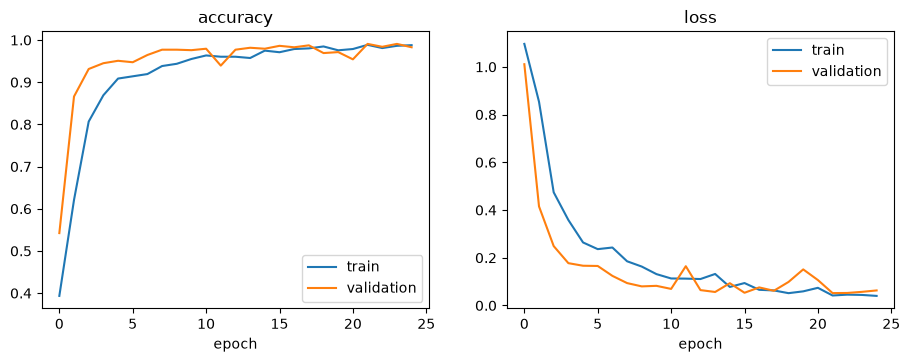

In [7]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(11, 3.6))

ax_acc.plot(history.history["accuracy"], label="train")
ax_acc.plot(history.history["val_accuracy"], label="validation")
ax_acc.set_title("accuracy")

ax_loss.plot(history.history["loss"], label="train")
ax_loss.plot(history.history["val_loss"], label="validation")
ax_loss.set_title("loss")

for ax in (ax_acc, ax_loss):
    ax.set_xlabel("epoch")
    ax.legend()

plt.show()

In [8]:
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"validation accuracy: {val_acc:.1%}")
print(f"validation loss:     {val_loss:.3f}")

validation accuracy: 99.1%
validation loss:     0.052


In [9]:
rng = np.random.default_rng(7)
n_per_class = 25
print('sample of', n_per_class, 'images per class, preprocessed like app.py:')
print()

for cls in CLASSES:
    files = sorted((DATA_DIR / cls).glob('*.png'))
    picked = rng.choice(len(files), size=n_per_class, replace=False)
    correct = 0
    for i in picked:
        img = load_img(files[i], target_size=IMG_SIZE)
        x = img_to_array(img) / 255.0
        probs = model.predict(np.expand_dims(x, 0), verbose=0)[0]
        correct += CLASSES[int(np.argmax(probs))] == cls
    print(f'{cls:>8}: {correct}/{n_per_class} called correctly')

sample of 25 images per class, preprocessed like app.py:



   paper: 25/25 called correctly


    rock: 25/25 called correctly


scissors: 25/25 called correctly


In [10]:
model.save("model.h5")